In [1]:
# DMFNet_BrainTumor_Classification.ipynb

import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torchvision import transforms, models
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from tqdm import tqdm
from PIL import Image


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.metrics import roc_curve, auc, classification_report, confusion_matrix
from sklearn.preprocessing import label_binarize
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import DataLoader

In [3]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [4]:
# Original data paths
ORIGINAL_BASE_DIR = r"C:\Users\manav\Documents\lighTumorNet\Brain_Tumor_MRI_Dataset"
ORIGINAL_TRAIN_DIR = os.path.join(ORIGINAL_BASE_DIR, "Training")
ORIGINAL_TEST_DIR = os.path.join(ORIGINAL_BASE_DIR, "Testing")

# Create new directory for preprocessed data (sibling to original base)
PROCESSED_BASE_DIR = os.path.join(os.path.dirname(ORIGINAL_BASE_DIR), "Processed_Brain_Tumor_MRI_Dataset")
PROCESSED_TRAIN_DIR = os.path.join(PROCESSED_BASE_DIR, "Training")
PROCESSED_TEST_DIR = os.path.join(PROCESSED_BASE_DIR, "Testing")

# Image parameters
IMG_HEIGHT = 150
IMG_WIDTH = 150
CHANNELS = 3
BATCH_SIZE = 32

# Create processed directories if they don't exist
os.makedirs(PROCESSED_BASE_DIR, exist_ok=True)
os.makedirs(PROCESSED_TRAIN_DIR, exist_ok=True)
os.makedirs(PROCESSED_TEST_DIR, exist_ok=True)

# Class names
CLASS_NAMES = ['glioma', 'meningioma', 'notumor', 'pituitary']

# Create class directories in processed folders
for class_name in CLASS_NAMES:
    os.makedirs(os.path.join(PROCESSED_TRAIN_DIR, class_name), exist_ok=True)
    os.makedirs(os.path.join(PROCESSED_TEST_DIR, class_name), exist_ok=True)

print("Directory structure created successfully!")

Directory structure created successfully!


In [5]:
train_transform = transforms.Compose([
    transforms.Lambda(lambda img: Image.fromarray(img) if isinstance(img, np.ndarray) else img),
    transforms.RandomRotation(10),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.002,0.002), shear=10),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

test_transform = transforms.Compose([
    transforms.Lambda(lambda img: Image.fromarray(img) if isinstance(img, np.ndarray) else img),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

In [6]:
try:
    BrainTumorDataset  # if defined earlier
except NameError:
    import cv2
    class BrainTumorDataset(torch.utils.data.Dataset):
        def __init__(self, root_dir, transform=None):
            self.root_dir = root_dir
            self.transform = transform
            self.classes = CLASS_NAMES
            self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}
            self.samples = []
            for class_name in self.classes:
                class_dir = os.path.join(root_dir, class_name)
                if os.path.exists(class_dir):
                    for img_name in os.listdir(class_dir):
                        if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                            self.samples.append((os.path.join(class_dir, img_name), self.class_to_idx[class_name]))
        def __len__(self):
            return len(self.samples)
        def __getitem__(self, idx):
            img_path, label = self.samples[idx]
            image = cv2.imread(img_path)
            if image is None:
                raise ValueError(f"Failed to read image at {img_path}")
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            if self.transform:
                image = self.transform(image)
            return image, int(label)


In [7]:
_num_workers = 0 if os.name == 'nt' else min(4, (os.cpu_count() or 1))
train_dataset = BrainTumorDataset(root_dir=PROCESSED_TRAIN_DIR, transform=train_transform)
test_dataset  = BrainTumorDataset(root_dir=PROCESSED_TEST_DIR, transform=test_transform)

# Pre-check: raise a clear error if datasets are empty (prevents RandomSampler num_samples=0)
if len(train_dataset) == 0:
    raise RuntimeError(f"No training samples found in '{PROCESSED_TRAIN_DIR}'. Check the path and that class subfolders exist. cwd={os.getcwd()}")
if len(test_dataset) == 0:
    raise RuntimeError(f"No test samples found in '{PROCESSED_TEST_DIR}'. Check the path and that class subfolders exist. cwd={os.getcwd()}")

# Create data loaders (safe settings for Windows / notebooks)
pin_mem = True if torch.cuda.is_available() else False
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=_num_workers, pin_memory=pin_mem)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=_num_workers, pin_memory=pin_mem)

print(f"Samples - Train: {len(train_dataset)} | Test: {len(test_dataset)} | Classes: {len(CLASS_NAMES)}")


Samples - Train: 5712 | Test: 1311 | Classes: 4


In [8]:
class DepthAttentionModule(nn.Module):
    def __init__(self, in_channels, reduction=16):
        super().__init__()
        mid = max(in_channels // reduction, 4)
        self.avg = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(in_channels, mid, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(mid, in_channels, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)

class DMFNet(nn.Module):
    def __init__(self, num_classes=4, backbone="mobilenetv3", shallow_layer_index=3):
        """
        backbone: "mobilenetv3" or "efficientnet_b0"
        shallow_layer_index: index at which to take the 'shallow' feature map from backbone.features
        """
        super().__init__()
        # load backbone
        if backbone == "mobilenetv3":
            base = models.mobilenet_v3_large(pretrained=True)
            backbone_features = base.features  # nn.Sequential
        elif backbone == "efficientnet_b0":
            base = models.efficientnet_b0(pretrained=True)
            backbone_features = base.features
        else:
            raise ValueError("Unsupported backbone")
        self.backbone_name = backbone
        self.backbone_features = backbone_features

        # store shallow idx for forward and create an explicit shallow feature nn.Sequential
        # TorchScript doesn't allow slicing a Sequential at runtime, so build the shallow module here
        self.shallow_layer_index = shallow_layer_index
        modules = list(self.backbone_features.children())
        # guard shallow index
        if not isinstance(self.shallow_layer_index, int) or self.shallow_layer_index < 0:
            raise ValueError("shallow_layer_index must be a non-negative int")
        shallow_modules = modules[:self.shallow_layer_index]
        self.shallow_features = nn.Sequential(*shallow_modules) if len(shallow_modules) > 0 else nn.Identity()
        self.deep_features = self.backbone_features

        # probe shapes by running a dummy input through the explicit modules
        dummy = torch.randn(1, 3, 224, 224)
        self.backbone_features.eval()
        with torch.no_grad():
            shallow_out = self.shallow_features(dummy)
            deep_out = self.deep_features(dummy)
        shallow_ch = shallow_out.shape[1]
        deep_ch = deep_out.shape[1]

        # Depth Attention on deep features
        self.depth_att = DepthAttentionModule(deep_ch, reduction=16)

        # channel reducers -> to fixed 128 each (keeps head small)
        self.reduce_shallow = nn.Conv2d(shallow_ch, 128, kernel_size=1)
        self.reduce_deep = nn.Conv2d(deep_ch, 128, kernel_size=1)

        # fusion conv
        self.fusion_conv = nn.Sequential(
            nn.Conv2d(256, 256, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.15)
        )

        # classifier: global pool + compact FC
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(256, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.35),
            nn.Linear(256, num_classes)
        )

        # (self.shallow_layer_index already set above)

        # initialize small layers
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
            elif isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        # shallow features (use pre-built module to keep TorchScript happy)
        shallow_feat = self.shallow_features(x)
        # deep features
        deep_feat = self.deep_features(x)

        # apply depth attention
        deep_feat = self.depth_att(deep_feat)

        # resize shallow -> deep spatial dims
        if shallow_feat.shape[2:] != deep_feat.shape[2:]:
            shallow_feat = nn.functional.interpolate(shallow_feat, size=deep_feat.shape[2:], mode='bilinear', align_corners=False)

        # reduce channels
        s = self.reduce_shallow(shallow_feat)
        d = self.reduce_deep(deep_feat)

        fused = torch.cat([s, d], dim=1)  # (B, 256, H, W)
        fused = self.fusion_conv(fused)

        out = self.classifier(fused)
        return out


In [9]:
model = DMFNet(num_classes=len(CLASS_NAMES), backbone="mobilenetv3", shallow_layer_index=3).to(device)
print(model)

c:\Users\manav\miniconda3\envs\efficientnet\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\manav\miniconda3\envs\efficientnet\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V3_Large_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V3_Large_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


DMFNet(
  (backbone_features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        )
      )
    )
    (2): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1)

In [10]:
# ---------- training setup ----------
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=4, verbose=True)

# ---------- training loop -----
EPOCHS = 50
best_val_loss = float('inf')
patience = 6
patience_counter = 0

train_losses, train_accs = [], []
val_losses, val_accs = [], []

if len(train_dataset) == 0 or len(test_dataset) == 0:
    raise RuntimeError("Datasets empty: check processed dirs and preprocessing cells")

print("Starting DMFNet training...")
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for imgs, labels in tqdm(train_loader, desc=f"Train Epoch {epoch+1}/{EPOCHS}"):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = outputs.max(1)
        total += labels.size(0)
        correct += preds.eq(labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = 100. * correct / total
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # validation
    model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0
    all_outputs = []
    all_labels = []
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item()
            _, preds = outputs.max(1)
            val_total += labels.size(0)
            val_correct += preds.eq(labels).sum().item()
            all_outputs.append(outputs.cpu())
            all_labels.append(labels.cpu())

    val_loss = val_running_loss / len(test_loader)
    val_acc = 100. * val_correct / val_total
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    # scheduler
    scheduler.step(val_loss)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

    # early stopping & best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "dmfnet_best.pth")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

print("Training finished. Best val loss:", best_val_loss)


c:\Users\manav\miniconda3\envs\efficientnet\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Starting DMFNet training...


Train Epoch 1/50: 100%|██████████| 179/179 [00:50<00:00,  3.52it/s]


Epoch 1/50 | Train Loss: 1.0892 | Train Acc: 56.16% | Val Loss: 2.7999 | Val Acc: 30.89%


Train Epoch 2/50: 100%|██████████| 179/179 [00:47<00:00,  3.76it/s]


...

Epoch 42/50 | Train Loss: 0.0360 | Train Acc: 98.74% | Val Loss: 0.0454 | Val Acc: 98.93%


Train Epoch 43/50: 100%|██████████| 179/179 [00:48<00:00,  3.72it/s]


Epoch 43/50 | Train Loss: 0.0286 | Train Acc: 99.11% | Val Loss: 0.0340 | Val Acc: 99.01%


Train Epoch 44/50: 100%|██████████| 179/179 [00:48<00:00,  3.72it/s]


Epoch 44/50 | Train Loss: 0.0243 | Train Acc: 99.14% | Val Loss: 0.0361 | Val Acc: 98.93%
Early stopping triggered.
Training finished. Best val loss: 0.03388692404565163


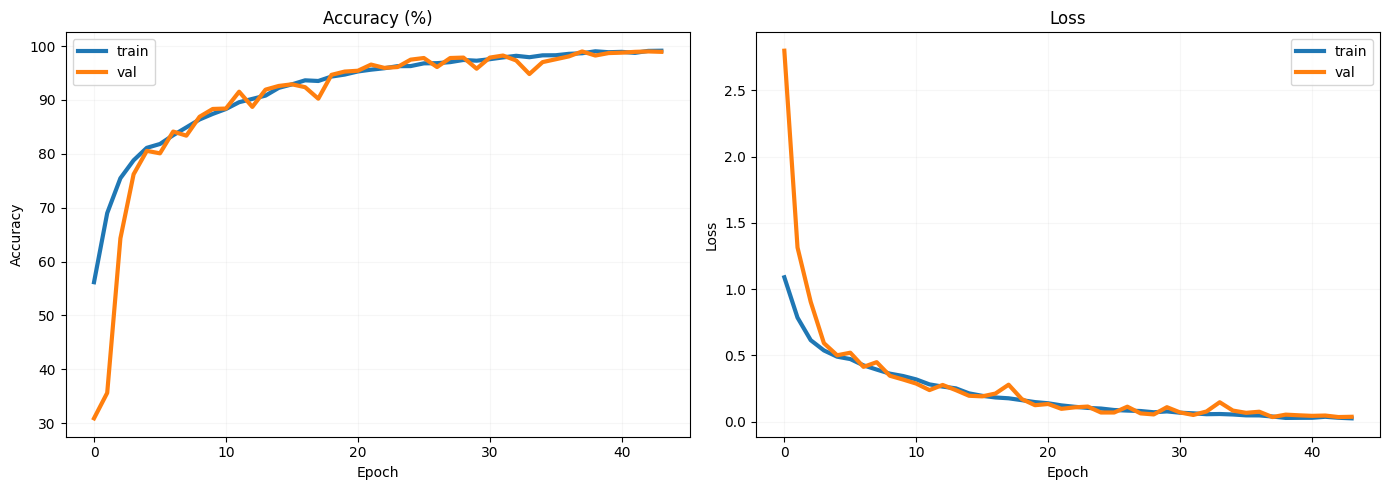

In [11]:
plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
plt.plot(train_accs, label='train', linewidth=3)
plt.plot(val_accs, label='val', linewidth=3)
plt.title("Accuracy (%)"); plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend(); plt.grid(alpha=0.1)
plt.subplot(1,2,2)
plt.plot(train_losses, label='train', linewidth=3)
plt.plot(val_losses, label='val', linewidth=3)
plt.title("Loss"); plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.grid(alpha=0.1)
plt.tight_layout(); plt.show()


C:\Users\manav\AppData\Local\Temp\ipykernel_9576\380716144.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("dmfnet_best.pth", map_locati

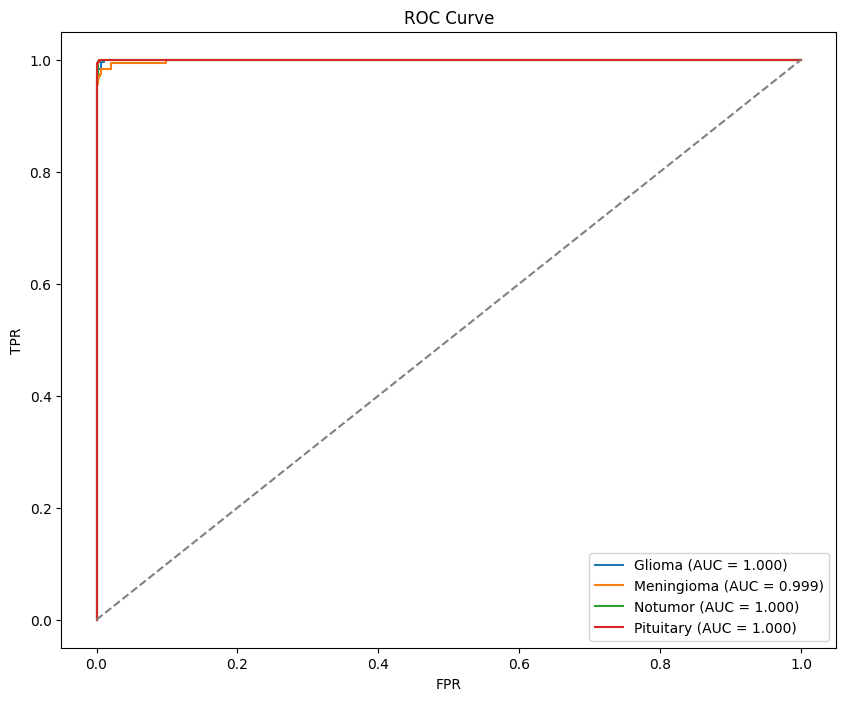

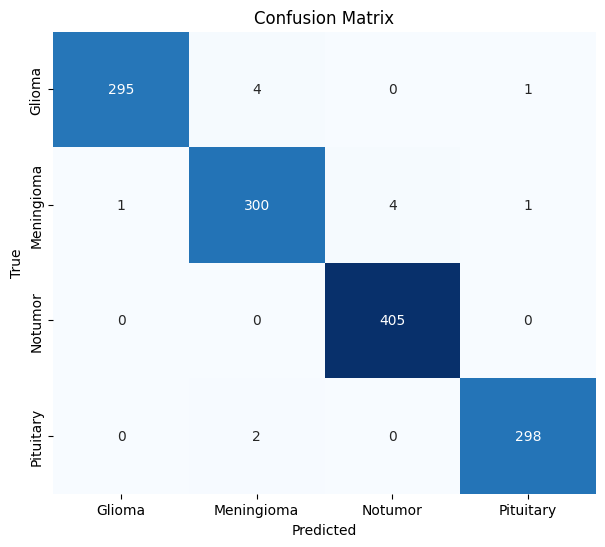

Classification Report:

              precision    recall  f1-score   support

      Glioma   0.996622  0.983333  0.989933       300
  Meningioma   0.980392  0.980392  0.980392       306
     Notumor   0.990220  1.000000  0.995086       405
   Pituitary   0.993333  0.993333  0.993333       300

    accuracy                       0.990084      1311
   macro avg   0.990142  0.989265  0.989686      1311
weighted avg   0.990103  0.990084  0.990076      1311



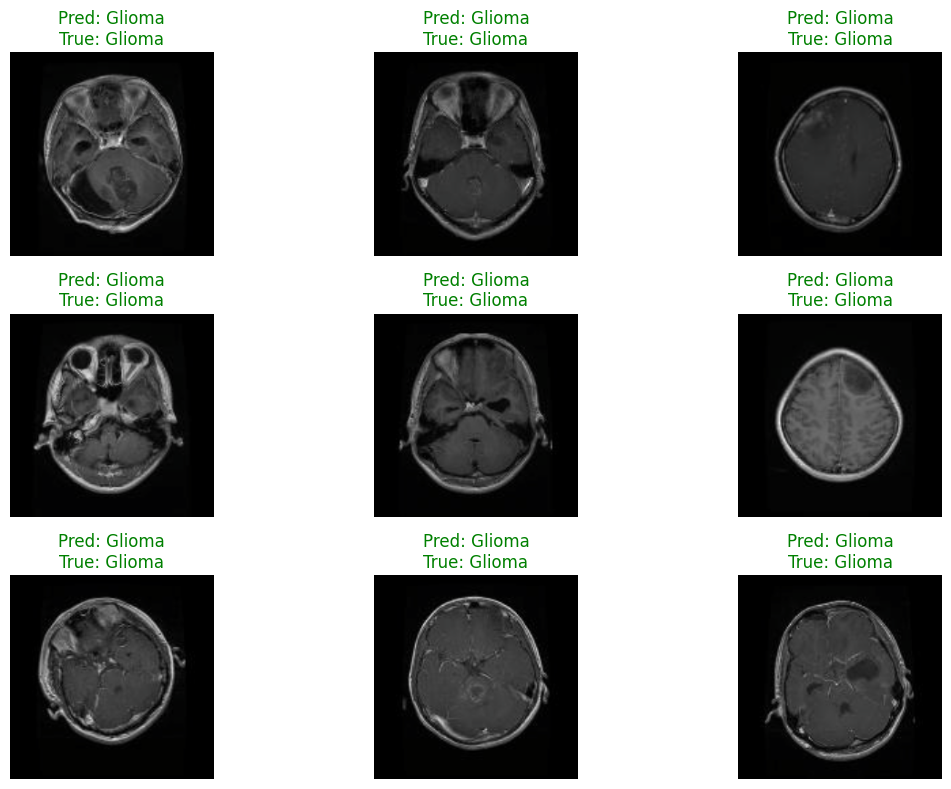

In [12]:
model.load_state_dict(torch.load("dmfnet_best.pth", map_location=device))
model.eval()

all_probs = []
all_preds = []
all_true = []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        probs = torch.softmax(outputs, dim=1)
        preds = probs.argmax(dim=1).cpu().numpy()
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds)
        all_true.extend(labels.numpy())

all_probs = np.array(all_probs)
all_preds = np.array(all_preds)
all_true = np.array(all_true)

# ROC curves & AUC
plt.figure(figsize=(10,8))
y_true_bin = label_binarize(all_true, classes=np.arange(len(CLASS_NAMES)))
for i, cname in enumerate(CLASS_NAMES):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{cname.title()} (AUC = {roc_auc:.3f})")
plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("ROC Curve"); plt.legend(); plt.show()

# confusion matrix
cm = confusion_matrix(all_true, all_preds)
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=[n.title() for n in CLASS_NAMES],
            yticklabels=[n.title() for n in CLASS_NAMES])
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Confusion Matrix"); plt.show()

# classification report
print("Classification Report:\n")
print(classification_report(all_true, all_preds, target_names=[n.title() for n in CLASS_NAMES], digits=6))

# sample predictions helper
def plot_sample_predictions(model, loader, num_samples=9, figsize=(12,8)):
    model.eval()
    imgs_show, preds_show, labels_show = [], [], []
    with torch.no_grad():
        for imgs, labels in loader:
            outputs = model(imgs.to(device))
            _, preds = outputs.max(1)
            imgs_show.extend(imgs.cpu())
            preds_show.extend(preds.cpu())
            labels_show.extend(labels)
            if len(imgs_show) >= num_samples:
                break
    imgs_show = imgs_show[:num_samples]
    preds_show = preds_show[:num_samples]
    labels_show = labels_show[:num_samples]

    plt.figure(figsize=figsize)
    for i, img in enumerate(imgs_show):
        img_np = img.permute(1,2,0).numpy()
        img_np = img_np * np.array([0.229,0.224,0.225]) + np.array([0.485,0.456,0.406])
        img_np = np.clip(img_np, 0, 1)
        plt.subplot(3,3,i+1)
        plt.imshow(img_np)
        color = "green" if preds_show[i]==labels_show[i] else "red"
        plt.title(f"Pred: {CLASS_NAMES[preds_show[i]].title()}\nTrue: {CLASS_NAMES[labels_show[i]].title()}", color=color)
        plt.axis("off")
    plt.tight_layout(); plt.show()

plot_sample_predictions(model, test_loader, num_samples=9)


In [13]:
# Dynamic quantization reduces FC/Linear sizes dramatically; good for CPU deployment.
quantized = torch.quantization.quantize_dynamic(model, {nn.Linear}, dtype=torch.qint8)
torch.save(quantized.state_dict(), "dmfnet_quantized.pth")
size_mb = os.path.getsize("dmfnet_quantized.pth") / 1e6
print(f"Quantized model size: {size_mb:.3f} MB")

# TorchScript export for deployment (scripted quantized model)
try:
    scripted = torch.jit.script(quantized)
    scripted.save("dmfnet_quantized_scripted.pt")
    print("TorchScript saved: dmfnet_quantized_scripted.pt")
except Exception as e:
    print("TorchScript scripting failed:", e)

# Print final size and quick summary
print("Final summary:")
print(f"Train samples: {len(train_dataset)} | Test samples: {len(test_dataset)}")
print(f"Classes: {CLASS_NAMES}")
print(f"Quantized weights file size (MB): {size_mb:.3f}")


Quantized model size: 15.216 MB
TorchScript scripting failed: false INTERNAL ASSERT FAILED at "C:\\cb\\pytorch_1000000000000\\work\\aten\\src\\ATen\\quantized\\Quantizer.cpp":445, please report a bug to PyTorch. cannot call qscheme on UnknownQuantizer
Final summary:
Train samples: 5712 | Test samples: 1311
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Quantized weights file size (MB): 15.216


In [14]:
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np
import torch

# ======================================
# CONFIGURATION
# ======================================
NUM_FOLDS = 5
BATCH_SIZE = 32
SEED = 42
MODEL_PATH = "dmfnet_best.pth"   # or "dmfnet_quantized.pth"
USE_QUANTIZED = False            # set True if using quantized weights

torch.manual_seed(SEED)
np.random.seed(SEED)

# ======================================
# PREPARE DATASET (same preprocessing as training)
# ======================================
full_dataset = BrainTumorDataset(
    root_dir=PROCESSED_TRAIN_DIR,
    transform=test_transform  # use deterministic preprocessing for eval
)
print(f"Total samples for cross-validation: {len(full_dataset)}")

kf = KFold(n_splits=NUM_FOLDS, shuffle=True, random_state=SEED)

fold_metrics = []

# ======================================
# EVALUATE ON EACH FOLD
# ======================================
for fold, (train_idx, val_idx) in enumerate(kf.split(full_dataset)):
    print(f"\n========== Fold {fold+1}/{NUM_FOLDS} ==========")

    val_sub = torch.utils.data.Subset(full_dataset, val_idx)
    val_loader = DataLoader(val_sub, batch_size=BATCH_SIZE, shuffle=False)

    # --- Load model ---
    if USE_QUANTIZED:
        model = DMFNet(num_classes=len(CLASS_NAMES), backbone="mobilenetv3").to("cpu")
        model.load_state_dict(torch.load(MODEL_PATH, map_location="cpu"))
        model.eval()
    else:
        model = DMFNet(num_classes=len(CLASS_NAMES), backbone="mobilenetv3").to(device)
        model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
        model.eval()

    y_true_all, y_pred_all = [], []

    # --- Inference ---
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs = imgs.to("cpu") if USE_QUANTIZED else imgs.to(device)
            outputs = model(imgs)
            preds = torch.argmax(outputs, dim=1)
            y_true_all.extend(labels.numpy())
            y_pred_all.extend(preds.cpu().numpy())

    # --- Compute metrics for this fold ---
    acc = accuracy_score(y_true_all, y_pred_all) * 100
    prec = precision_score(y_true_all, y_pred_all, average='macro')
    rec = recall_score(y_true_all, y_pred_all, average='macro')
    f1 = f1_score(y_true_all, y_pred_all, average='macro')

    fold_metrics.append((acc, prec, rec, f1))
    print(f"Fold {fold+1} | Acc: {acc:.2f}% | Prec: {prec:.3f} | Recall: {rec:.3f} | F1: {f1:.3f}")

# ======================================
# SUMMARY
# ======================================
import pandas as pd
df = pd.DataFrame(fold_metrics, columns=["Accuracy", "Precision", "Recall", "F1"])
df.loc["Mean"] = df.mean()
df.loc["Std"] = df.std()
print("\n========== Cross-Validation Summary ==========")
print(df)


Total samples for cross-validation: 5712

========== Fold 1/5 ==========


c:\Users\manav\miniconda3\envs\efficientnet\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\manav\miniconda3\envs\efficientnet\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V3_Large_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V3_Large_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
C:\Users\manav\AppData\Local\Temp\ipykernel_9576\444184890.py:47: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling

Fold 1 | Acc: 99.83% | Prec: 0.998 | Recall: 0.998 | F1: 0.998

========== Fold 2/5 ==========


c:\Users\manav\miniconda3\envs\efficientnet\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\manav\miniconda3\envs\efficientnet\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V3_Large_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V3_Large_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
C:\Users\manav\AppData\Local\Temp\ipykernel_9576\444184890.py:47: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling

Fold 2 | Acc: 99.74% | Prec: 0.997 | Recall: 0.997 | F1: 0.997

========== Fold 3/5 ==========


...

Fold 3 | Acc: 100.00% | Prec: 1.000 | Recall: 1.000 | F1: 1.000

========== Fold 4/5 ==========


c:\Users\manav\miniconda3\envs\efficientnet\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\manav\miniconda3\envs\efficientnet\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V3_Large_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V3_Large_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
C:\Users\manav\AppData\Local\Temp\ipykernel_9576\444184890.py:47: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling

Fold 4 | Acc: 99.91% | Prec: 0.999 | Recall: 0.999 | F1: 0.999

========== Fold 5/5 ==========


c:\Users\manav\miniconda3\envs\efficientnet\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\manav\miniconda3\envs\efficientnet\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V3_Large_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V3_Large_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
C:\Users\manav\AppData\Local\Temp\ipykernel_9576\444184890.py:47: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling

Fold 5 | Acc: 99.82% | Prec: 0.998 | Recall: 0.998 | F1: 0.998

========== Cross-Validation Summary ==========
        Accuracy  Precision    Recall        F1
0      99.825022   0.998276  0.998113  0.998188
1      99.737533   0.997288  0.997292  0.997288
2     100.000000   1.000000  1.000000  1.000000
3      99.912434   0.999094  0.999057  0.999074
4      99.824869   0.998165  0.998165  0.998165
Mean   99.859972   0.998565  0.998525  0.998543
Std     0.089225   0.000918  0.000925  0.000922


In [15]:
df.to_csv("dmfnet_crossval_results.csv", index=True)


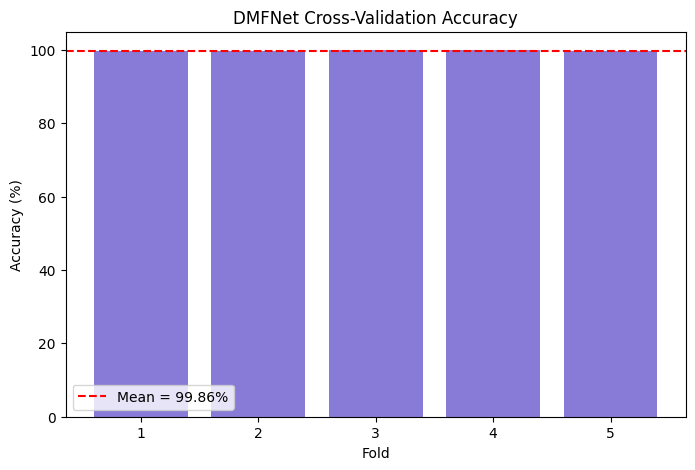

In [16]:
plt.figure(figsize=(8,5))
plt.bar(range(1, NUM_FOLDS+1), df.iloc[:-2]["Accuracy"], color="#6a5acd", alpha=0.8)
plt.axhline(df.loc["Mean","Accuracy"], color="red", linestyle="--", label=f"Mean = {df.loc['Mean','Accuracy']:.2f}%")
plt.title("DMFNet Cross-Validation Accuracy")
plt.xlabel("Fold")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.show()


In [17]:
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np
import torch

# ======================================
# CONFIGURATION
# ======================================
NUM_FOLDS = 5
BATCH_SIZE = 32
SEED = 42
MODEL_PATH = "dmfnet_quantized.pth"   # quantized weights file

torch.manual_seed(SEED)
np.random.seed(SEED)

# ======================================
# PREPARE DATASET
# ======================================
full_dataset = BrainTumorDataset(
    root_dir=PROCESSED_TRAIN_DIR,
    transform=test_transform  # deterministic transform for eval
)
print(f"Total samples for cross-validation: {len(full_dataset)}")

kf = KFold(n_splits=NUM_FOLDS, shuffle=True, random_state=SEED)
fold_metrics = []

# ======================================
# EVALUATE QUANTIZED MODEL ACROSS FOLDS
# ======================================
for fold, (train_idx, val_idx) in enumerate(kf.split(full_dataset)):
    print(f"\n========== Quantized Fold {fold+1}/{NUM_FOLDS} ==========")

    val_sub = torch.utils.data.Subset(full_dataset, val_idx)
    val_loader = DataLoader(val_sub, batch_size=BATCH_SIZE, shuffle=False)

    # Load base architecture
    model = DMFNet(num_classes=len(CLASS_NAMES), backbone="mobilenetv3").to("cpu")

    # Apply dynamic quantization wrapper
    model = torch.quantization.quantize_dynamic(model, {nn.Linear}, dtype=torch.qint8)
    model.load_state_dict(torch.load(MODEL_PATH, map_location="cpu"))
    model.eval()

    y_true_all, y_pred_all = [], []

    # Inference
    with torch.no_grad():
        for imgs, labels in val_loader:
            outputs = model(imgs.to("cpu"))
            preds = torch.argmax(outputs, dim=1)
            y_true_all.extend(labels.numpy())
            y_pred_all.extend(preds.cpu().numpy())

    # Compute metrics
    acc = accuracy_score(y_true_all, y_pred_all) * 100
    prec = precision_score(y_true_all, y_pred_all, average='macro')
    rec = recall_score(y_true_all, y_pred_all, average='macro')
    f1 = f1_score(y_true_all, y_pred_all, average='macro')

    fold_metrics.append((acc, prec, rec, f1))
    print(f"Fold {fold+1} | Acc: {acc:.2f}% | Prec: {prec:.3f} | Recall: {rec:.3f} | F1: {f1:.3f}")

# ======================================
# SUMMARY
# ======================================
import pandas as pd
df_q = pd.DataFrame(fold_metrics, columns=["Accuracy", "Precision", "Recall", "F1"])
df_q.loc["Mean"] = df_q.mean()
df_q.loc["Std"] = df_q.std()

print("\n========== Quantized Model Cross-Validation Summary ==========")
print(df_q)

# Save to CSV
df_q.to_csv("dmfnet_quantized_crossval.csv", index=True)


Total samples for cross-validation: 5712

========== Quantized Fold 1/5 ==========


c:\Users\manav\miniconda3\envs\efficientnet\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\manav\miniconda3\envs\efficientnet\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V3_Large_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V3_Large_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
C:\Users\manav\AppData\Local\Temp\ipykernel_9576\343050013.py:43: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling

Fold 1 | Acc: 99.91% | Prec: 0.999 | Recall: 0.999 | F1: 0.999

========== Quantized Fold 2/5 ==========


c:\Users\manav\miniconda3\envs\efficientnet\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\manav\miniconda3\envs\efficientnet\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V3_Large_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V3_Large_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
C:\Users\manav\AppData\Local\Temp\ipykernel_9576\343050013.py:43: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling

Fold 2 | Acc: 99.74% | Prec: 0.997 | Recall: 0.997 | F1: 0.997

========== Quantized Fold 3/5 ==========


...

Fold 3 | Acc: 100.00% | Prec: 1.000 | Recall: 1.000 | F1: 1.000

========== Quantized Fold 4/5 ==========


c:\Users\manav\miniconda3\envs\efficientnet\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\manav\miniconda3\envs\efficientnet\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V3_Large_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V3_Large_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
C:\Users\manav\AppData\Local\Temp\ipykernel_9576\343050013.py:43: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling

Fold 4 | Acc: 99.91% | Prec: 0.999 | Recall: 0.999 | F1: 0.999

========== Quantized Fold 5/5 ==========


c:\Users\manav\miniconda3\envs\efficientnet\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\manav\miniconda3\envs\efficientnet\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V3_Large_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V3_Large_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
C:\Users\manav\AppData\Local\Temp\ipykernel_9576\343050013.py:43: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling

Fold 5 | Acc: 99.82% | Prec: 0.998 | Recall: 0.998 | F1: 0.998

========== Quantized Model Cross-Validation Summary ==========
        Accuracy  Precision    Recall        F1
0      99.912511   0.999135  0.999057  0.999094
1      99.737533   0.997288  0.997292  0.997288
2     100.000000   1.000000  1.000000  1.000000
3      99.912434   0.999094  0.999057  0.999074
4      99.824869   0.998165  0.998165  0.998165
Mean   99.877469   0.998737  0.998714  0.998724
Std     0.089234   0.000928  0.000918  0.000923


Test samples: 1311


c:\Users\manav\miniconda3\envs\efficientnet\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\manav\miniconda3\envs\efficientnet\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V3_Large_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V3_Large_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
C:\Users\manav\AppData\Local\Temp\ipykernel_9576\2098862390.py:50: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpicklin


========== Full DMFNet Evaluation ==========
Accuracy: 99.01%

              precision    recall  f1-score   support

      Glioma   0.996622  0.983333  0.989933       300
  Meningioma   0.980392  0.980392  0.980392       306
     Notumor   0.990220  1.000000  0.995086       405
   Pituitary   0.993333  0.993333  0.993333       300

    accuracy                       0.990084      1311
   macro avg   0.990142  0.989265  0.989686      1311
weighted avg   0.990103  0.990084  0.990076      1311



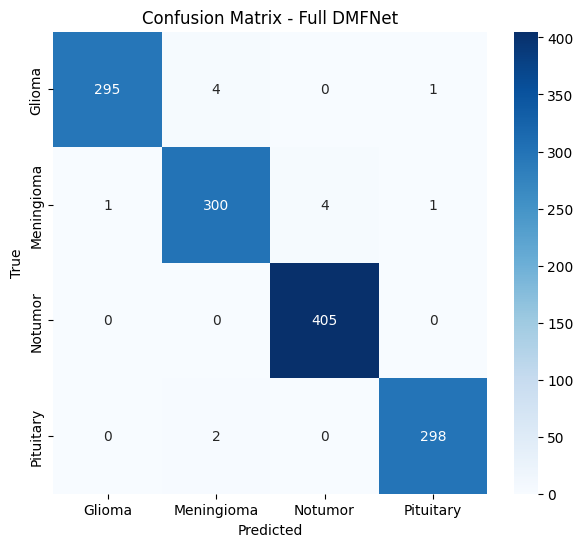


========== Quantized DMFNet Evaluation ==========
Accuracy: 98.93%

              precision    recall  f1-score   support

      Glioma   0.993266  0.983333  0.988275       300
  Meningioma   0.980328  0.977124  0.978723       306
     Notumor   0.990220  1.000000  0.995086       405
   Pituitary   0.993333  0.993333  0.993333       300

    accuracy                       0.989321      1311
   macro avg   0.989287  0.988448  0.988854      1311
weighted avg   0.989321  0.989321  0.989307      1311



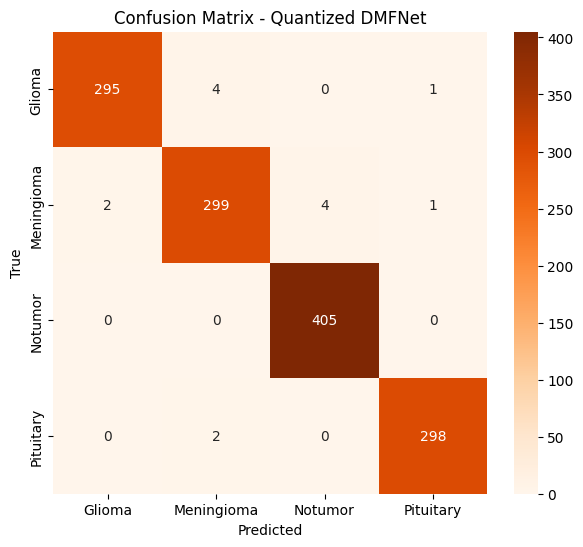


========== Comparison Summary ==========
Full Model Accuracy     : 99.01%
Quantized Model Accuracy: 98.93%
Accuracy Drop           : 0.08%

Model Sizes: Full = 15.76 MB | Quantized = 15.22 MB | Reduction = 3.4%


In [18]:
import torch
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# =====================================
# CONFIGURATION
# =====================================
TEST_DIR = r"C:\Users\manav\Documents\lighTumorNet\Processed_Brain_Tumor_MRI_Dataset\Testing"
MODEL_FULL_PATH = "dmfnet_best.pth"
MODEL_QUANT_PATH = "dmfnet_quantized.pth"

BATCH_SIZE = 32

# =====================================
# PREPARE TEST DATA
# =====================================
test_dataset = BrainTumorDataset(root_dir=TEST_DIR, transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Test samples: {len(test_dataset)}")

# =====================================
# EVALUATE FUNCTION
# =====================================
def evaluate_model(model, loader, device="cpu"):
    model.eval()
    all_preds, all_true = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            outputs = model(imgs)
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_true.extend(labels.numpy())

    acc = accuracy_score(all_true, all_preds) * 100
    report = classification_report(all_true, all_preds, target_names=[n.title() for n in CLASS_NAMES], digits=6)
    cm = confusion_matrix(all_true, all_preds)
    return acc, report, cm

# =====================================
# LOAD MODELS
# =====================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Full-precision model
model_full = DMFNet(num_classes=len(CLASS_NAMES), backbone="mobilenetv3").to(device)
model_full.load_state_dict(torch.load(MODEL_FULL_PATH, map_location=device))
model_full.eval()

# Quantized model
model_quant = DMFNet(num_classes=len(CLASS_NAMES), backbone="mobilenetv3").to("cpu")
model_quant = torch.quantization.quantize_dynamic(model_quant, {nn.Linear}, dtype=torch.qint8)
model_quant.load_state_dict(torch.load(MODEL_QUANT_PATH, map_location="cpu"))
model_quant.eval()

# =====================================
# TEST FULL MODEL
# =====================================
print("\n========== Full DMFNet Evaluation ==========")
acc_full, report_full, cm_full = evaluate_model(model_full, test_loader, device=device)
print(f"Accuracy: {acc_full:.2f}%\n")
print(report_full)

plt.figure(figsize=(7,6))
sns.heatmap(cm_full, annot=True, fmt='d', cmap='Blues',
            xticklabels=[n.title() for n in CLASS_NAMES],
            yticklabels=[n.title() for n in CLASS_NAMES])
plt.title("Confusion Matrix - Full DMFNet")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# =====================================
# TEST QUANTIZED MODEL
# =====================================
print("\n========== Quantized DMFNet Evaluation ==========")
acc_quant, report_quant, cm_quant = evaluate_model(model_quant, test_loader, device="cpu")
print(f"Accuracy: {acc_quant:.2f}%\n")
print(report_quant)

plt.figure(figsize=(7,6))
sns.heatmap(cm_quant, annot=True, fmt='d', cmap='Oranges',
            xticklabels=[n.title() for n in CLASS_NAMES],
            yticklabels=[n.title() for n in CLASS_NAMES])
plt.title("Confusion Matrix - Quantized DMFNet")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# =====================================
# COMPARE BOTH
# =====================================
print("\n========== Comparison Summary ==========")
print(f"Full Model Accuracy     : {acc_full:.2f}%")
print(f"Quantized Model Accuracy: {acc_quant:.2f}%")
print(f"Accuracy Drop           : {acc_full - acc_quant:.2f}%")

size_full = os.path.getsize(MODEL_FULL_PATH)/1e6
size_quant = os.path.getsize(MODEL_QUANT_PATH)/1e6
print(f"\nModel Sizes: Full = {size_full:.2f} MB | Quantized = {size_quant:.2f} MB | Reduction = {100*(1 - size_quant/size_full):.1f}%")
